In [21]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [22]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True
)

test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor(),
    download = True
)

In [23]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [24]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [25]:
train_data.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [26]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [27]:
train_data.targets.size()

torch.Size([60000])

In [28]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [29]:
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader(train_data,
                        batch_size = 100 , 
                        shuffle = True,
                        num_workers = 1),
    'test' : DataLoader(test_data,
                        batch_size = 100,
                        shuffle = True,
                        num_workers = 1),
}

In [30]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x138b376d0>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x138b35840>}

In [34]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)

        return x

In [36]:
import torch 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(loaders['train']):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = loss_fn(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f'Training Epoch: {epoch} [{batch_idx * len(data)} / {len(loaders["train"].dataset)} ({100 * batch_idx / len(loaders["train"]):.0f}%)]\t{loss.item():.6f}')


def test():
    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += loss_fn(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(loaders['test'])

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy {correct}/{len(loaders["test"].dataset)} ({100. * correct / len(loaders["test"].dataset):.0f}%)\n')

In [37]:
for epoch in range(1,11):
    train(epoch)
    test()

Training Epoch: 1 [0 / 60000 (0%)]	2.317839
Training Epoch: 1 [2000 / 60000 (3%)]	2.168624
Training Epoch: 1 [4000 / 60000 (7%)]	1.626298
Training Epoch: 1 [6000 / 60000 (10%)]	1.140744
Training Epoch: 1 [8000 / 60000 (13%)]	1.054918
Training Epoch: 1 [10000 / 60000 (17%)]	0.801464
Training Epoch: 1 [12000 / 60000 (20%)]	0.703663
Training Epoch: 1 [14000 / 60000 (23%)]	0.627115
Training Epoch: 1 [16000 / 60000 (27%)]	0.646254
Training Epoch: 1 [18000 / 60000 (30%)]	0.634620
Training Epoch: 1 [20000 / 60000 (33%)]	0.576820
Training Epoch: 1 [22000 / 60000 (37%)]	0.492498
Training Epoch: 1 [24000 / 60000 (40%)]	0.738804
Training Epoch: 1 [26000 / 60000 (43%)]	0.385032
Training Epoch: 1 [28000 / 60000 (47%)]	0.486841
Training Epoch: 1 [30000 / 60000 (50%)]	0.399976
Training Epoch: 1 [32000 / 60000 (53%)]	0.406725
Training Epoch: 1 [34000 / 60000 (57%)]	0.505032
Training Epoch: 1 [36000 / 60000 (60%)]	0.386488
Training Epoch: 1 [38000 / 60000 (63%)]	0.423455
Training Epoch: 1 [40000 / 6000

In [38]:
device

device(type='cpu')

Prediction: 6


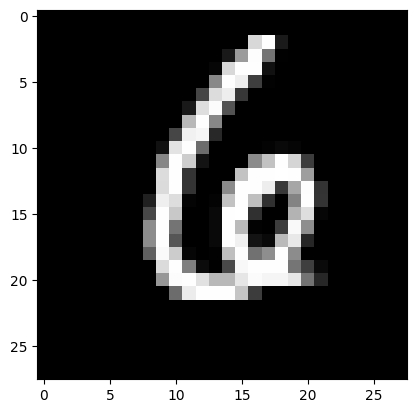

In [44]:
import matplotlib.pyplot as plt

model.eval()

data, target = test_data[123]

data = data.unsqueeze(0).to(device)

output = model(data)

prediction = output.argmax(dim = 1 , keepdim = True).item()

print(f'Prediction: {prediction}')

image = data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')
plt.show()